In [9]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.insert(0, str(PROJECT_ROOT))
Path.cwd()

PosixPath('/home/avash/Documents/research/transformer-pt-analysis-main/src/Analysis')

seed 97: t_g=1104.1  Delta_t=319.1  M0=0.0000  dM=1.0000
seed 8: t_g=1598.9  Delta_t=212.7  M0=0.0382  dM=0.9532
seed 64: t_g=2993.2  Delta_t=249.7  M0=0.0410  dM=0.9533
seed 50: t_g=1463.5  Delta_t=663.8  M0=0.0000  dM=1.0000
seed 65: t_g=1199.1  Delta_t=320.6  M0=0.0000  dM=1.0000
seed 95: t_g=680.9  Delta_t=220.3  M0=0.0000  dM=1.0000
seed 12: t_g=1100.8  Delta_t=255.5  M0=0.0076  dM=0.9852
seed 59: t_g=1837.0  Delta_t=398.6  M0=0.0230  dM=0.9742
seed 76: t_g=2738.0  Delta_t=313.1  M0=0.0362  dM=0.9544
seed 37: t_g=332.5  Delta_t=492.1  M0=0.0000  dM=1.0000

--- Summary across seeds ---
t_g     = 1504.80 ± 795.44
Delta_t = 344.54 ± 133.63
dM      = 0.9820 ± 0.0203

Relative t_g spread (std/mean Delta_t): 2.31


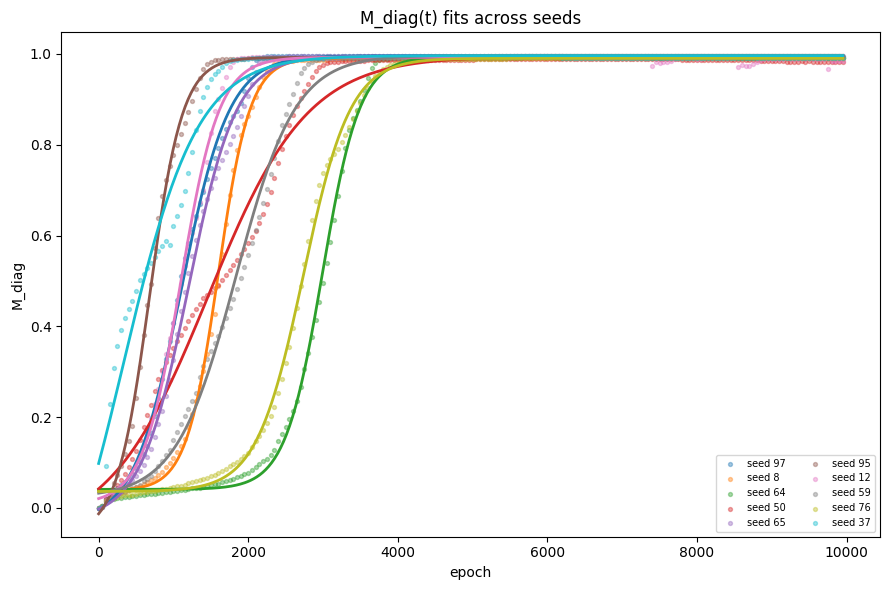

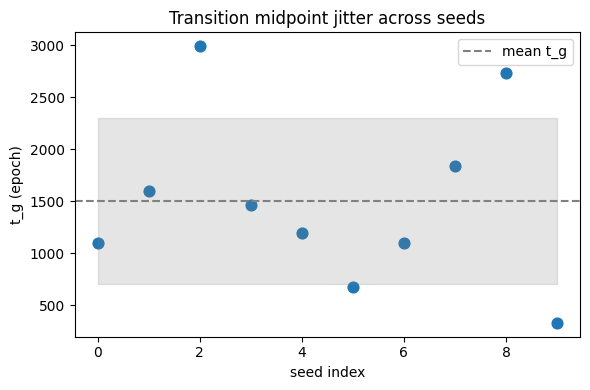

In [10]:
import os
import torch
from mintrans_clean import *
import analysis as a

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

files = os.listdir('./random_seeds')

path_wd = [{ "wd": decay.split('wd')[-1 :][0].split('_')[-1:][0].split('.pth')[0], "path": decay }for decay in files]


cfg = TrainConfig()

all_results = [] 

for obj in path_wd:
    path = os.path.join("random_seeds", obj['path'])
    random_seed = obj['wd']

    model = MinimalTransformer(
        vocab_size=cfg.vocab_size, d_model=cfg.d_model, n_heads=cfg.n_heads,
        num_layers=cfg.num_layers, max_seq_len=cfg.seq_len,
        hidden_mlp=cfg.hidden_mlp,
    ).to(device)

    skeletons = torch.load(path, map_location=device)

    history = skeletons['history']

    # plot_training_curves(history, title=f"p={cfg.p}, d={cfg.d_model} seed={random_seed}")
    # plot_spectral_history(history, title=f"Diagonal spectral mass during training seed={random_seed}")

    # Looks like we are saving the checkpoint on every 50 epoch.
    spectal_mass = [{
        "d_mass": props['diag_mass'],
        "epoch": props['epoch']
    } for props in history['spectral']]

    epochs = [pt['epoch'] for pt in spectal_mass]
    d_mass = [pt['d_mass'] for pt in spectal_mass]

    try:
        r = a.fit_one_run(epochs, d_mass)
        r['seed'] = random_seed
        all_results.append(r)
        print(f"seed {random_seed}: t_g={r['t_g']:.1f}  Delta_t={r['Delta_t']:.1f}  "
              f"M0={r['M0']:.4f}  dM={r['dM']:.4f}")
    except RuntimeError as e:
        print(f"seed {random_seed}: fit FAILED ({e})")

# ---------------------------------------------------------------------------
# AGGREGATE ACROSS ALL SEEDS (after the loop finishes)
# ---------------------------------------------------------------------------
t_g_vals     = np.array([r['t_g'] for r in all_results])
Delta_t_vals = np.array([r['Delta_t'] for r in all_results])
dM_vals      = np.array([r['dM'] for r in all_results])



print("\n--- Summary across seeds ---")
# at t = tg = m = 0.5
print(f"t_g     = {t_g_vals.mean():.2f} ± {t_g_vals.std():.2f}")
print(f"Delta_t = {Delta_t_vals.mean():.2f} ± {Delta_t_vals.std():.2f}")
print(f"dM      = {dM_vals.mean():.4f} ± {dM_vals.std():.4f}")
print(f"\nRelative t_g spread (std/mean Delta_t): "
      f"{t_g_vals.std()/Delta_t_vals.mean():.2f}")

# ---------------------------------------------------------------------------
# PLOTS
# ---------------------------------------------------------------------------
plt.figure(figsize=(9,6))
colors = plt.cm.tab10(np.linspace(0, 1, len(all_results)))
for r, c in zip(all_results, colors):
    plt.scatter(r['epochs'], r['M'], s=8, alpha=0.4, color=c, label=f"seed {r['seed']}")
    t_fine = np.linspace(r['epochs'].min(), r['epochs'].max(), 500)
    plt.plot(t_fine, a.logistic(t_fine, *r['popt']), color=c, lw=2)


plt.xlabel("epoch"); plt.ylabel("M_diag")
plt.title("M_diag(t) fits across seeds")
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig("Mdiag_fits.png", dpi=150)
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(range(len(t_g_vals)), t_g_vals, s=60)
plt.axhline(t_g_vals.mean(), color='gray', ls='--', label='mean t_g')
plt.fill_between(range(len(t_g_vals)), t_g_vals.mean()-t_g_vals.std(),
                  t_g_vals.mean()+t_g_vals.std(), alpha=0.2, color='gray')
plt.xlabel("seed index"); plt.ylabel("t_g (epoch)")
plt.title("Transition midpoint jitter across seeds")
plt.legend(); plt.tight_layout()
plt.savefig("tg_scatter.png", dpi=150)
plt.show()

### Finite size scaling of the transition width

p=  17  n_seeds= 1  Delta_t/t_g = 0.2307 ± 0.0000
p=  31  n_seeds= 1  Delta_t/t_g = -3.1050 ± 0.0000
p=  59  n_seeds= 1  Delta_t/t_g = 0.2071 ± 0.0000
p=  97  n_seeds= 1  Delta_t/t_g = 0.2128 ± 0.0000
p= 113  n_seeds= 1  Delta_t/t_g = -1.6565 ± 0.0000
p= 149  n_seeds= 1  Delta_t/t_g = 0.1645 ± 0.0000

slope = nan   implied nu = nan
-> Delta_t/t_g increases with p: broader transitions at larger p


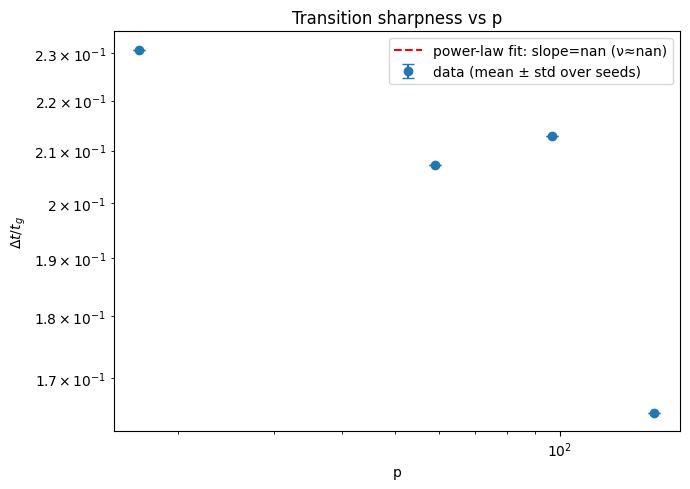

In [11]:
import os
import torch
from mintrans_clean import *
import analysis as a

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

files = os.listdir('./range_of_primes')

path_wd = [{ "wd": decay.split('wd')[-1 :][0].split('_')[-1:][0].split('.pth')[0], "path": decay }for decay in files]


cfg = TrainConfig()

all_results_multpile_p = [] 
p_values = []

for obj in path_wd:
    path = os.path.join("range_of_primes", obj['path'])
    p = obj['wd']
    p_values.append(int(p))

    model = MinimalTransformer(
        vocab_size=cfg.vocab_size, d_model=cfg.d_model, n_heads=cfg.n_heads,
        num_layers=cfg.num_layers, max_seq_len=cfg.seq_len,
        hidden_mlp=cfg.hidden_mlp,
    ).to(device)

    skeletons = torch.load(path, map_location=device)
 

    history = skeletons['history']

    xi = [pt['xi'] for pt in history['spectral']]
    peak = [pt['peak'] for pt in history['spectral']]

    #plot_training_curves(history, title=f"d={cfg.d_model} P={p}")
    # plot_spectral_history(history, title=f"Diagonal spectral mass during training seed={random_seed}")

    spectal_mass = [{
        "d_mass": props['diag_mass'],
        "epoch": props['epoch'],
    } for props in history['spectral']]

    epochs = [pt['epoch'] for pt in spectal_mass]
    d_mass = [pt['d_mass'] for pt in spectal_mass]

    r = a.fit_one_run(epochs, d_mass)
    r['p'] = int(p)
    r['xi'] = xi
    r['peak'] = peak
    all_results_multpile_p.append(r)


p_values = sorted(set(p_values))

a.summary_finite_size_scaling(
    p_values,
    all_results_multpile_p
)


### Mdiag hist

Reference epoch t_ref = 1504.8
M_diag(t_ref) across 10 seeds:
  values: [0.749 0.382 0.05  0.476 0.705 0.983 0.827 0.346 0.07  0.945]
  mean = 0.553, std = 0.322


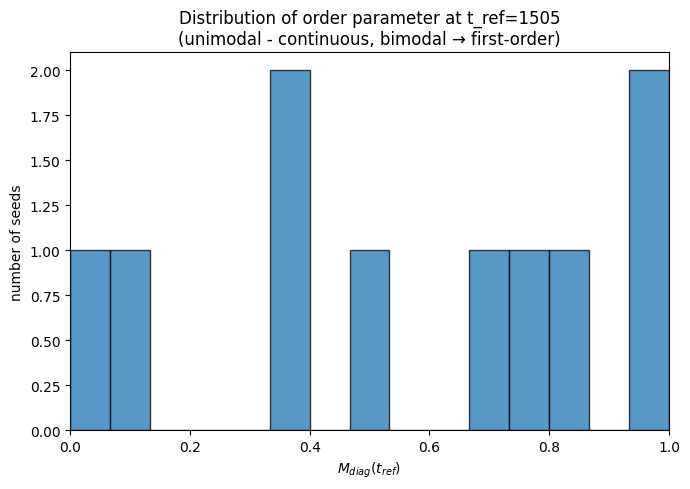

''

In [12]:
# Here we need it across multiple seeds.
a.plot_Mdiag_histogram(all_results)
""

p=17  xi_max=4.55  xi_max/p=0.2677
p=31  xi_max=69.02  xi_max/p=2.2265
p=59  xi_max=67.52  xi_max/p=1.1445
p=97  xi_max=630.41  xi_max/p=6.4991
p=113  xi_max=11532.84  xi_max/p=102.0606
p=149  xi_max=1072.31  xi_max/p=7.1967


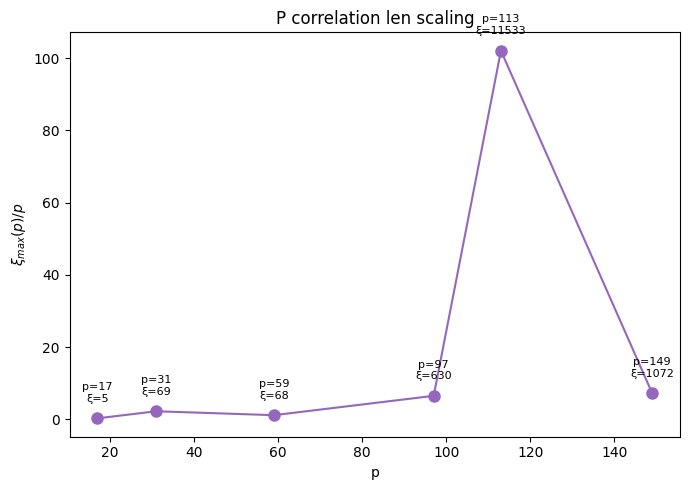

In [13]:
xi_max_by_p = {res['p']: max(res['xi']) for res in all_results_multpile_p}

p_arr = np.array(sorted(xi_max_by_p.keys()), dtype=float)
xi_max_arr = np.array([xi_max_by_p[p] for p in p_arr], dtype=float)
ratio = xi_max_arr / p_arr

for p, xm, r in zip(p_arr, xi_max_arr, ratio):
    print(f"p={p:.0f}  xi_max={xm:.2f}  xi_max/p={r:.4f}")

plt.figure(figsize=(7,5))
plt.plot(p_arr, ratio, 'o-', color='tab:purple', markersize=8)

# label each point with its p value
for p, r, xi in zip(p_arr, ratio, xi_max_arr):
    plt.annotate(
        f"p={p:.0f}\nξ={xi:.0f}",       
        xy=(p, r),
        xytext=(0, 12),
        textcoords='offset points',
        ha='center',
        fontsize=8,
        color='black'
    )

plt.xlabel('p')
plt.ylabel(r'$\xi_{max}(p) / p$')
plt.title(r'P correlation len scaling')
plt.tight_layout()
plt.show()

In [14]:
max_peak_prop = all_results_multpile_p[1]
print(len(max_peak_prop['xi'])) # 150 * 50 = 7500 calculated under each epoch.
print(max(max_peak_prop['xi']))

# S_peak is the value in fouirer space where S(kx, ky) is max in value
# lets say we have winding frequency in that pattern and we look at the neighbouts in fouierer space and check if they are correlated.

150
11532.84375


### Check that high correlation for p=113 again.

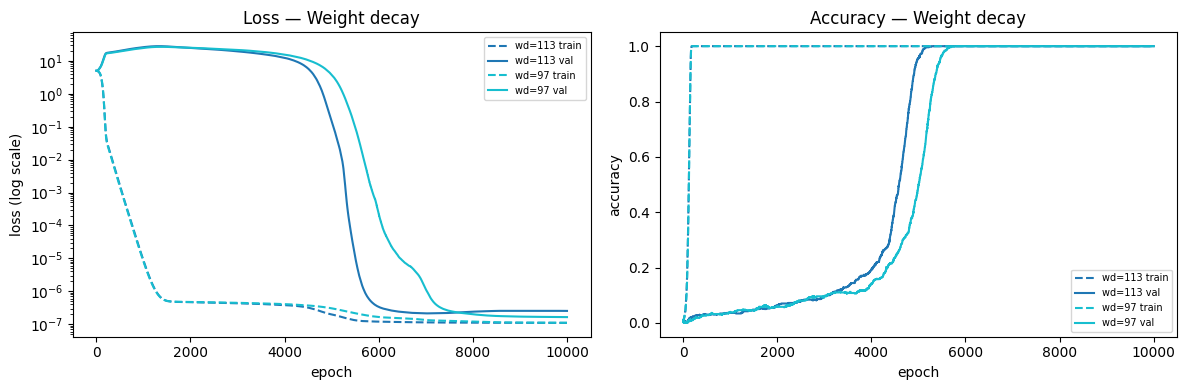

In [15]:
import os
import torch
from mintrans_clean import *
import analysis as a

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

files = os.listdir('./skeletons_choosed_p')

path_wd = [{ "wd": decay.split('wd')[-1 :][0].split('_')[-1:][0].split('.pth')[0], "path": decay }for decay in files]


cfg = TrainConfig()

result_across_selected_p = [] 
p_values = []
plot_data_selected_weight_decay = []

for obj in path_wd:
    path = os.path.join("skeletons_choosed_p", obj['path'])
    p = obj['wd']
    p_values.append(int(p))

    model = MinimalTransformer(
        vocab_size=cfg.vocab_size, d_model=cfg.d_model, n_heads=cfg.n_heads,
        num_layers=cfg.num_layers, max_seq_len=cfg.seq_len,
        hidden_mlp=cfg.hidden_mlp,
    ).to(device)

    skeletons = torch.load(path, map_location=device)
 

    history = skeletons['history']

    xi = [pt['xi'] for pt in history['spectral']]
    peak = [pt['peak'] for pt in history['spectral']]

    #plot_training_curves(history, title=f"d={cfg.d_model} P={p}")
    # plot_spectral_history(history, title=f"Diagonal spectral mass during training seed={random_seed}")

    spectal_mass = [{
        "d_mass": props['diag_mass'],
        "epoch": props['epoch'],
    } for props in history['spectral']]

    epochs = [pt['epoch'] for pt in spectal_mass]
    d_mass = [pt['d_mass'] for pt in spectal_mass]

    plot_data_selected_weight_decay.append((p, skeletons['history']))

    r = a.fit_one_run(epochs, d_mass)
    r['p'] = int(p)
    r['xi'] = xi
    r['peak'] = peak
    result_across_selected_p.append(r)


a.plot_training_curves_weight_decay(plot_data_selected_weight_decay, "Weight decay")


p=97  xi_max=170.38  xi_max/p=1.7565
p=113  xi_max=128.32  xi_max/p=1.1356
97.0
113.0


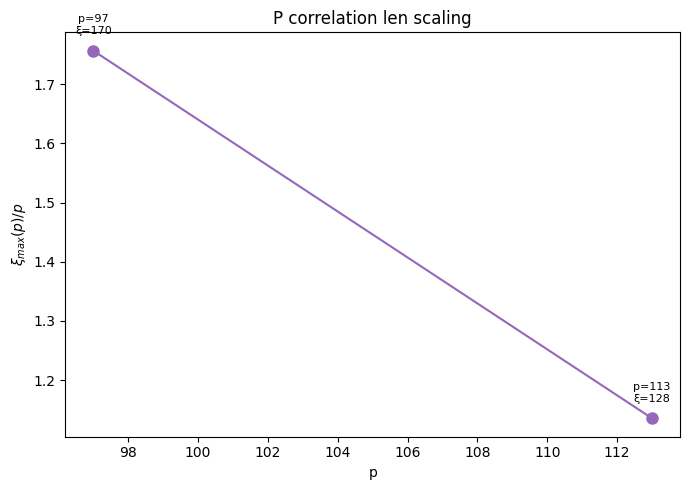

In [16]:
xi_max_by_p = {res['p']: max(res['xi']) for res in result_across_selected_p}

p_arr = np.array(sorted(xi_max_by_p.keys()), dtype=float)
xi_max_arr = np.array([xi_max_by_p[p] for p in p_arr], dtype=float)
ratio = xi_max_arr / p_arr

for p, xm, r in zip(p_arr, xi_max_arr, ratio):
    print(f"p={p:.0f}  xi_max={xm:.2f}  xi_max/p={r:.4f}")

plt.figure(figsize=(7,5))
plt.plot(p_arr, ratio, 'o-', color='tab:purple', markersize=8)

# label each point with its p value
for p, r, xi in zip(p_arr, ratio, xi_max_arr):
    print(p)
    plt.annotate(
        f"p={p:.0f}\nξ={xi:.0f}",       
        xy=(p, r),
        xytext=(0, 12),
        textcoords='offset points',
        ha='center',
        fontsize=8,
        color='black'
    )

plt.xlabel('p')
plt.ylabel(r'$\xi_{max}(p) / p$')
plt.title(r'P correlation len scaling')
plt.tight_layout()
plt.show()